<a href="https://colab.research.google.com/github/Tanish1109/ML-Model-to-Predict-Alzheimer-s-/blob/main/Alzeheimers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Saving alzheimers_disease_data.csv to alzheimers_disease_data (1).csv
   Age_Bucket  Healthy_Count  Alzheimers_Count  Total_Count
0          60            210               130          340
1          65            241               120          361
2          70            236               121          357
3          75            222               124          346
4          80            216               119          335
5          85            216               115          331
6          90             48                31           79


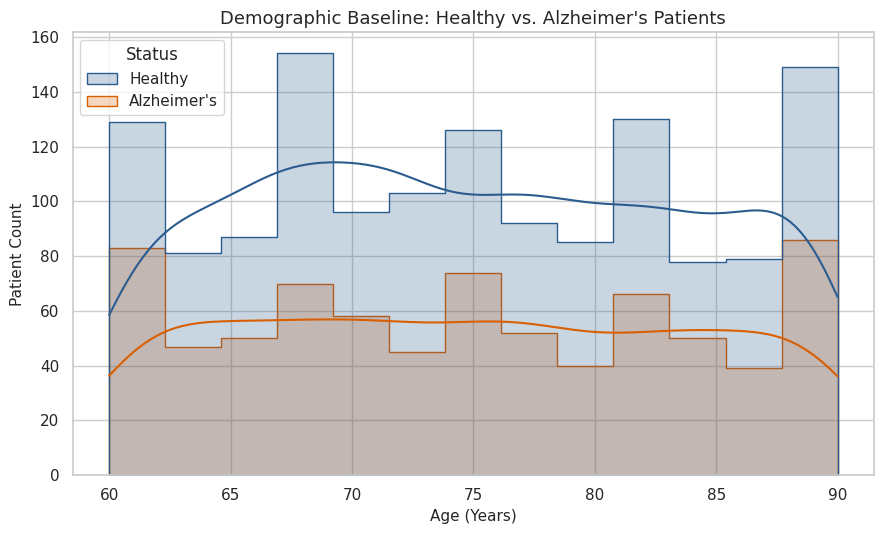

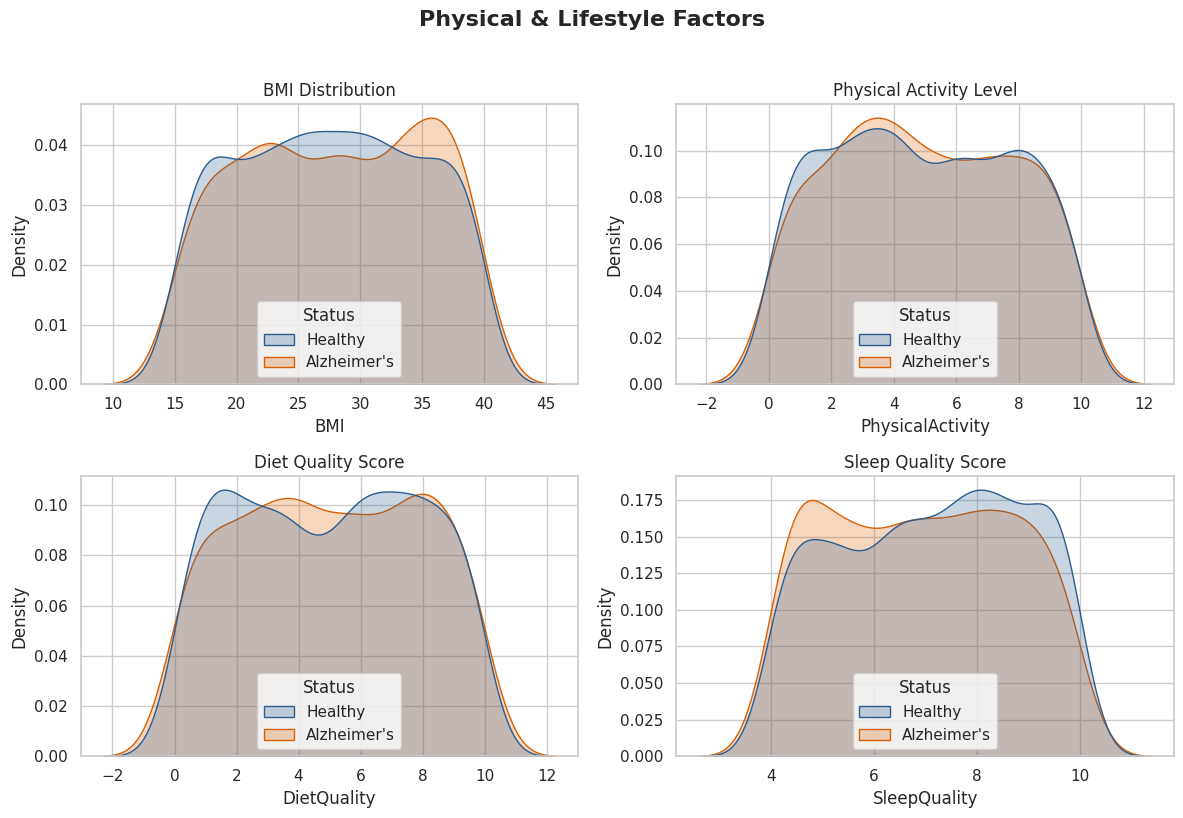

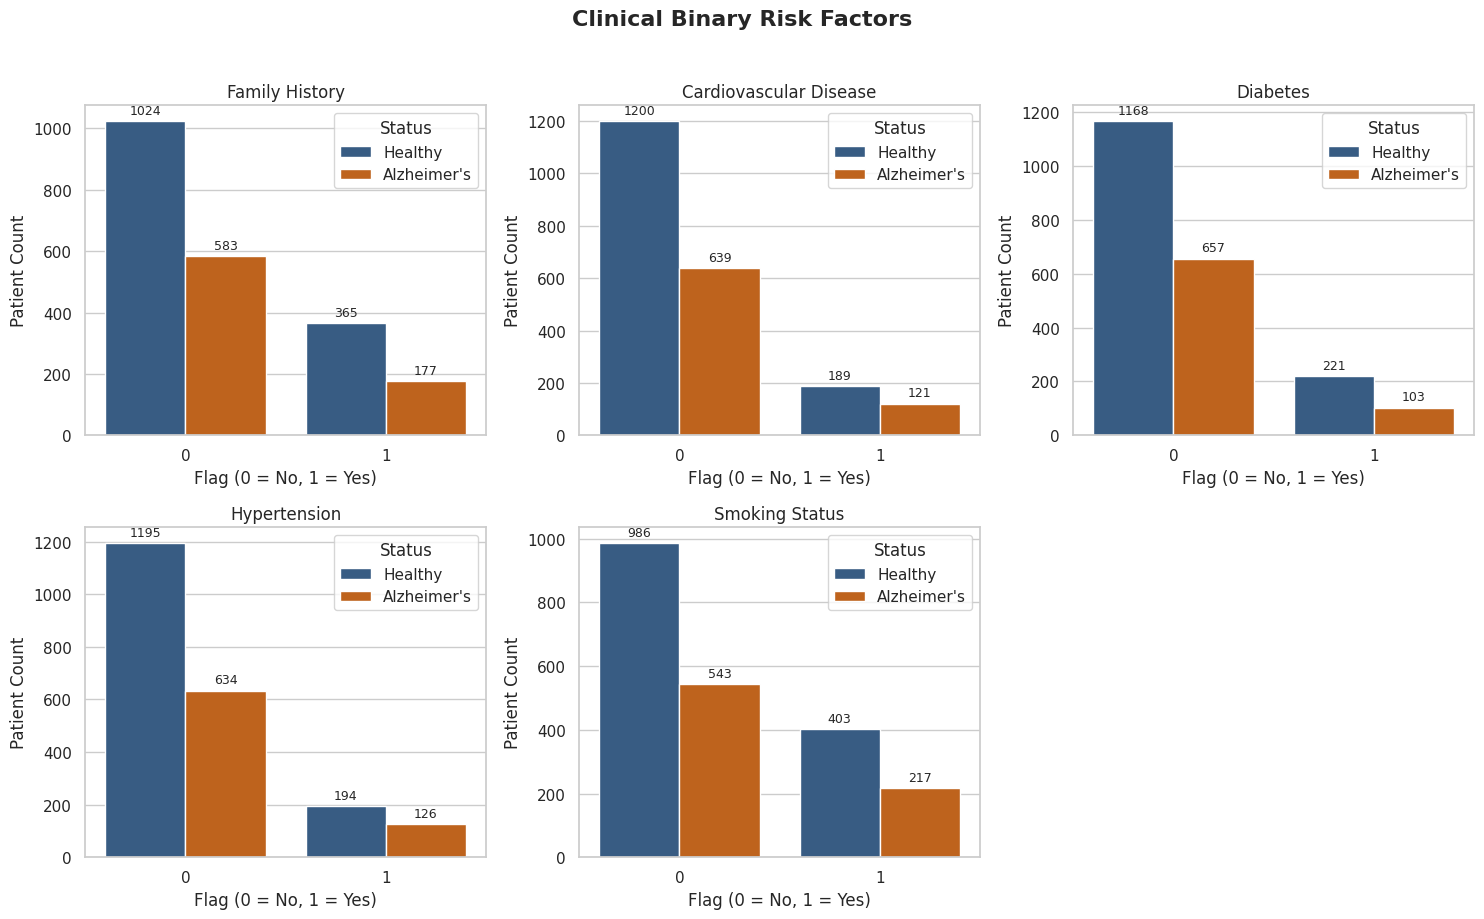

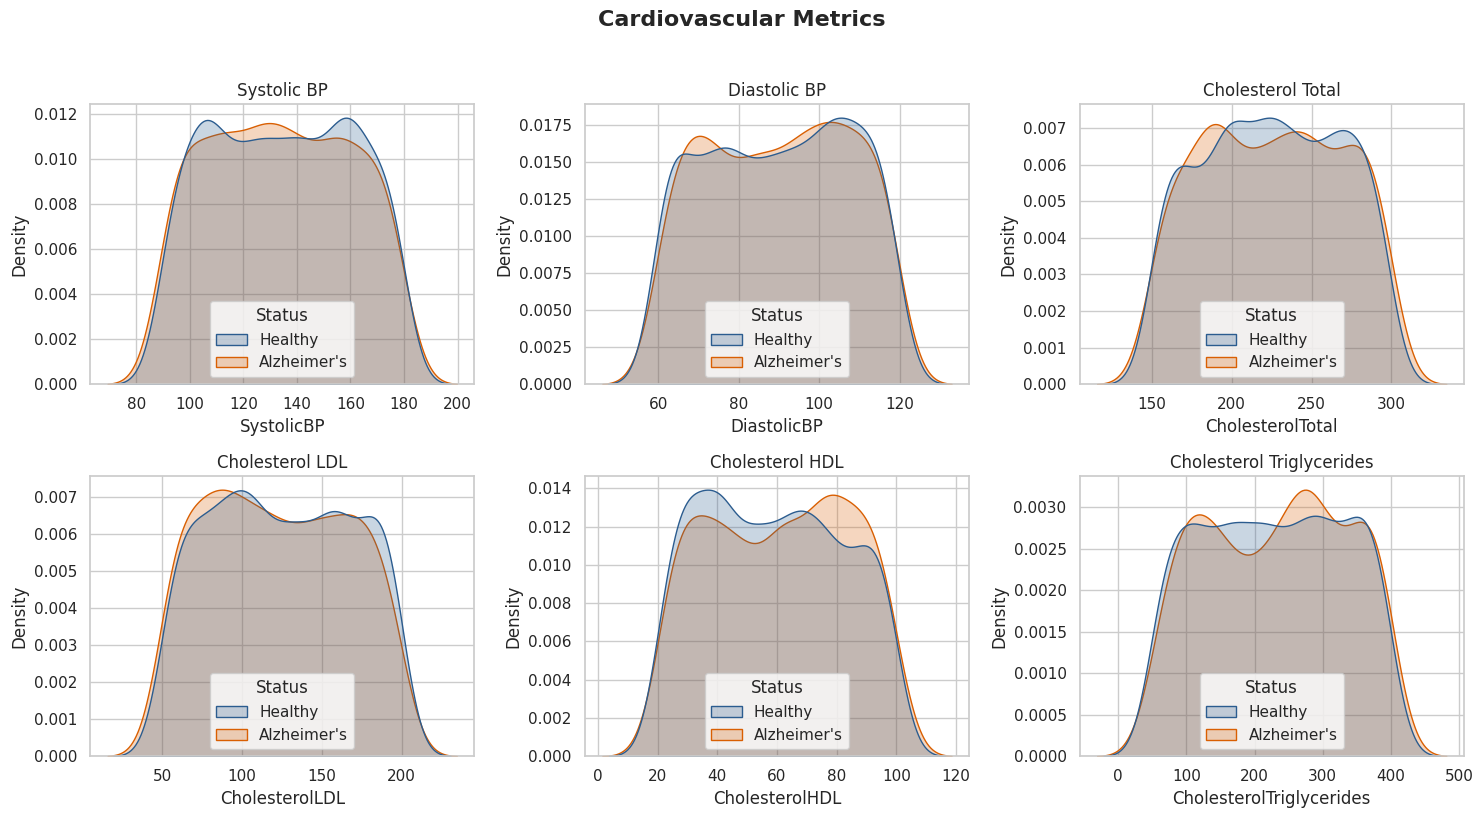

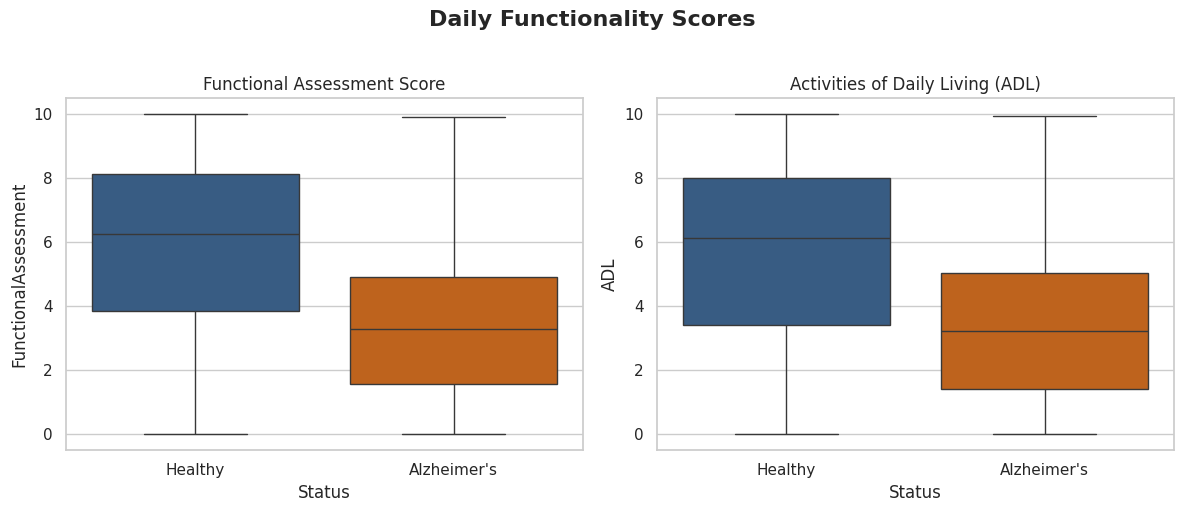

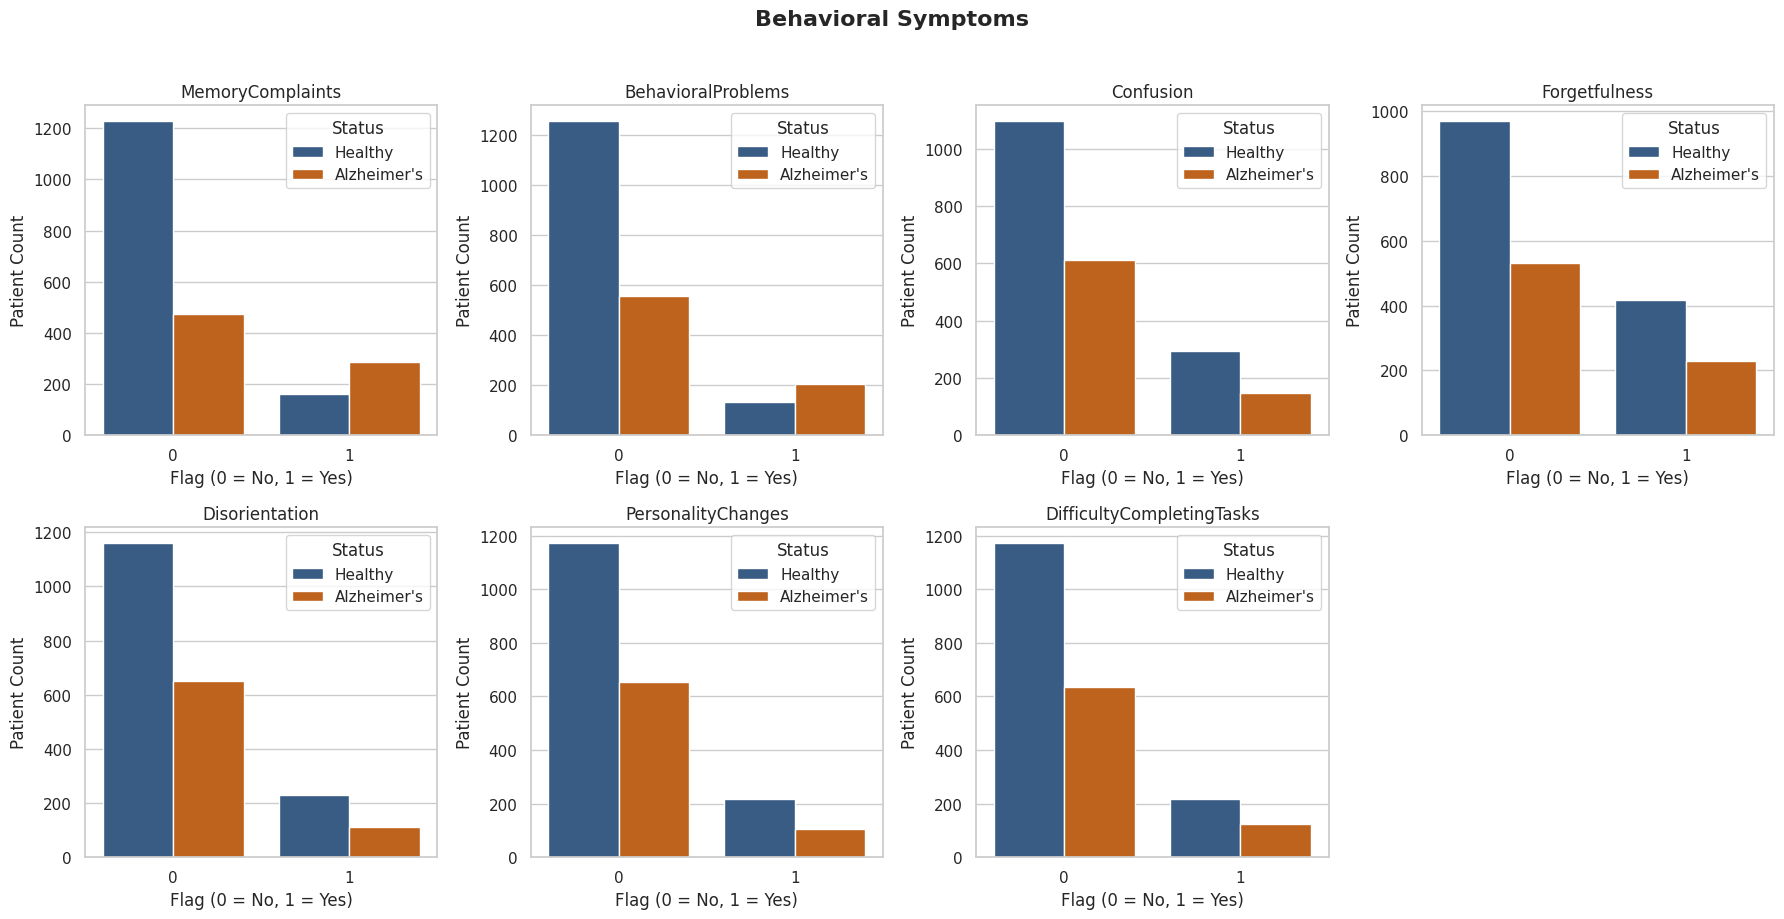

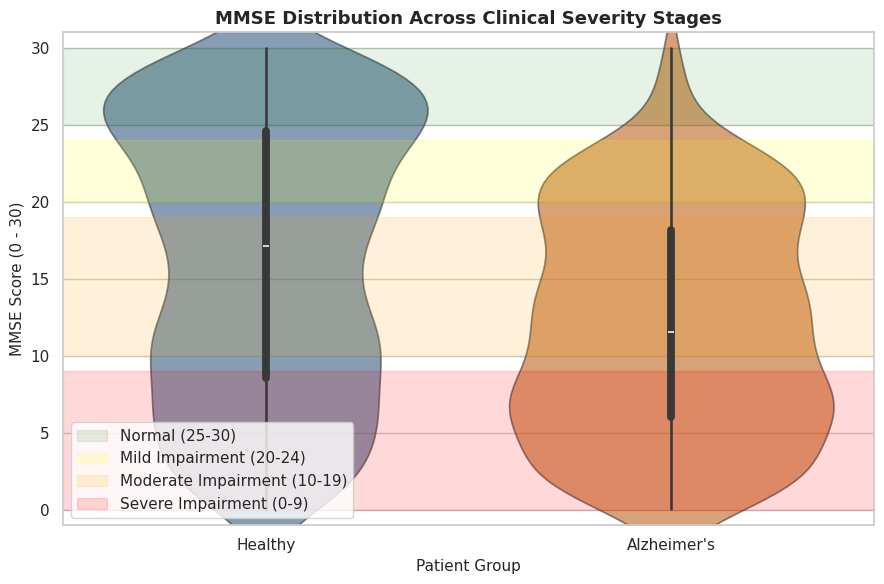

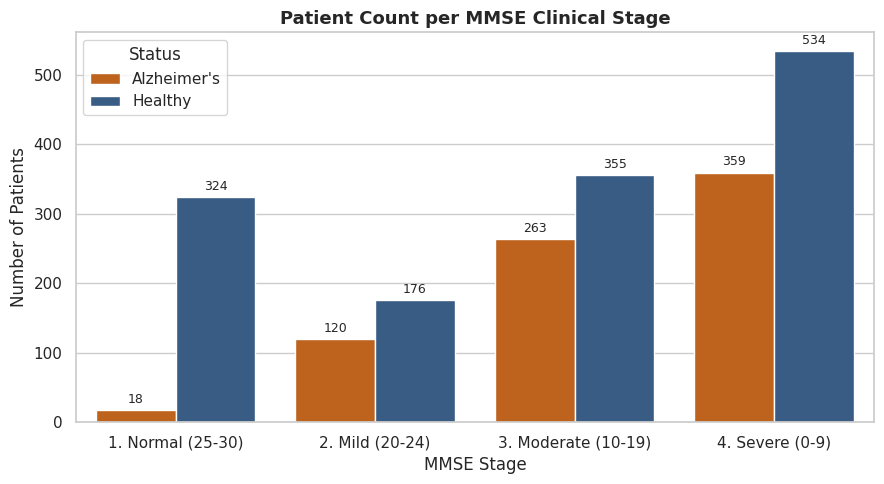

In [4]:
import sqlite3
from google.colab import files
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# Step 1: Upload File
uploaded = files.upload()

# Step 2: Load into Pandas & Save to SQLite
df = pd.read_csv('alzheimers_disease_data.csv')
conn = sqlite3.connect('alzheimers.db')
df.to_sql('alzheimers', conn, if_exists='replace', index=False)

# Step 3: Run SQL Query
query = """
SELECT
    FLOOR(Age / 5) * 5 AS Age_Bucket,
    SUM(CASE WHEN Diagnosis = 0 THEN 1 ELSE 0 END) AS Healthy_Count,
    SUM(CASE WHEN Diagnosis = 1 THEN 1 ELSE 0 END) AS Alzheimers_Count,
    COUNT(*) AS Total_Count
FROM alzheimers
GROUP BY Age_Bucket
ORDER BY Age_Bucket;
"""
df_summary = pd.read_sql_query(query, conn)
print(df_summary)

# Step 4: Plot Visualization
sns.set_theme(style='whitegrid')
df['Status'] = df['Diagnosis'].map({0: 'Healthy', 1: "Alzheimer's"})

fig_demographic = plt.figure(figsize=(9, 5.5))
sns.histplot(
    data=df,
    x='Age',
    hue='Status',
    kde=True,
    element='step',
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
    alpha=0.25,
)

plt.title("Demographic Baseline: Healthy vs. Alzheimer's Patients", fontsize=13)
plt.xlabel('Age (Years)', fontsize=11)
plt.ylabel('Patient Count', fontsize=11)

plt.tight_layout()
plt.show()
# Add an overall title above all subplots
fig_demographic.suptitle(
    'Demographic Baseline: Healthy vs. Alzheimer\'s Patients', fontsize=16, fontweight='bold', y=1.02
)

import matplotlib.pyplot as plt
import seaborn as sns

# Create a 2x2 grid of subplots
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle(
    'Physical & Lifestyle Factors', fontsize=16, fontweight='bold', y=1.02
)

# Column 1: BMI
sns.kdeplot(
    data=df,
    x='BMI',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[0, 0],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[0, 0].set_title('BMI Distribution')

# Column 2: Physical Activity
sns.kdeplot(
    data=df,
    x='PhysicalActivity',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[0, 1],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[0, 1].set_title('Physical Activity Level')

# Column 3: Diet Quality
sns.kdeplot(
    data=df,
    x='DietQuality',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[1, 0],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[1, 0].set_title('Diet Quality Score')

# Column 4: Sleep Quality
sns.kdeplot(
    data=df,
    x='SleepQuality',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[1, 1],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[1, 1].set_title('Sleep Quality Score')

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

# Set up a 2x3 grid for binary flags
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle(
    'Clinical Binary Risk Factors', fontsize=16, fontweight='bold', y=1.02
)

# List of binary columns to plot
binary_cols = [
    ('FamilyHistoryAlzheimers', 'Family History', axes[0, 0]),
    ('CardiovascularDisease', 'Cardiovascular Disease', axes[0, 1]),
    ('Diabetes', 'Diabetes', axes[0, 2]),
    ('Hypertension', 'Hypertension', axes[1, 0]),
    ('Smoking', 'Smoking Status', axes[1, 1]),
]

# Loop through columns and generate count plots
for col, title, ax in binary_cols:
  sns.countplot(
      data=df,
      x=col,
      hue='Status',
      palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
      ax=ax,
  )
  ax.set_title(title)
  ax.set_xlabel('Flag (0 = No, 1 = Yes)')
  ax.set_ylabel('Patient Count')

  # Add numbers above bars
  for p in ax.patches:
    if p.get_height() > 0:
      ax.annotate(
          f'{int(p.get_height())}',
          (p.get_x() + p.get_width() / 2.0, p.get_height()),
          ha='center',
          va='bottom',
          fontsize=9,
          xytext=(0, 3),
          textcoords='offset points',
      )

# Hide the unused 6th subplot frame (bottom-right)
fig.delaxes(axes[1, 2])

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle(
    'Cardiovascular Metrics', fontsize=16, fontweight='bold', y=1.02
)

sns.kdeplot(
    data=df,
    x='SystolicBP',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[0, 0],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[0, 0].set_title('Systolic BP')
sns.kdeplot(
    data=df,
    x='DiastolicBP',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[0, 1],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[0, 1].set_title('Diastolic BP')
sns.kdeplot(
    data=df,
    x='CholesterolTotal',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[0, 2],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[0, 2].set_title('Cholesterol Total')
sns.kdeplot(
    data=df,
    x='CholesterolLDL',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[1, 0],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[1, 0].set_title('Cholesterol LDL')
sns.kdeplot(
    data=df,
    x='CholesterolHDL',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[1, 1],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[1, 1].set_title('Cholesterol HDL')
sns.kdeplot(
    data=df,
    x='CholesterolTriglycerides',
    hue='Status',
    common_norm=False,
    fill=True,
    ax=axes[1, 2],
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
)
axes[1, 2].set_title('Cholesterol Triglycerides')
plt.tight_layout()
plt.show()


import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle(
    'Daily Functionality Scores', fontsize=16, fontweight='bold', y=1.02
)

sns.boxplot(
    data=df,
    x='Status',
    y='FunctionalAssessment',
    hue='Status',
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
    ax=axes[0],
)
axes[0].set_title('Functional Assessment Score')

sns.boxplot(
    data=df,
    x='Status',
    y='ADL',
    hue='Status',
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
    ax=axes[1],
)
axes[1].set_title('Activities of Daily Living (ADL)')
plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

import matplotlib.pyplot as plt
import seaborn as sns

# 1. List all 7 of your behavioral symptom column names
behavioral_cols = [
    'MemoryComplaints',
    'BehavioralProblems',
    'Confusion',
    'Forgetfulness',
    'Disorientation',
    'PersonalityChanges',
    'DifficultyCompletingTasks',
]

# 2. Create a 2x4 grid (8 slots total)
fig, axes = plt.subplots(2, 4, figsize=(18, 9))
fig.suptitle('Behavioral Symptoms', fontsize=16, fontweight='bold', y=1.02)

# Flatten axes array for easy 1D looping (axes[0], axes[1], ... axes[7])
axes_flat = axes.flatten()

# 3. Loop through columns and plot
for i, col in enumerate(behavioral_cols):
  sns.countplot(
      data=df,
      x=col,
      hue='Status',
      palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
      ax=axes_flat[i],
  )
  axes_flat[i].set_title(col)
  axes_flat[i].set_xlabel('Flag (0 = No, 1 = Yes)')
  axes_flat[i].set_ylabel('Patient Count')

# 4. Hide the unused 8th subplot box (bottom-right)
fig.delaxes(axes_flat[7])

plt.tight_layout()
plt.show()

import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# 1. Violin plot of MMSE Scores
sns.violinplot(
    data=df,
    x='Status',
    y='MMSE',
    hue='Status',
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
    inner='box',
    alpha=0.6,
    legend=False,
)

# 2. Add Shaded Background Bands for Severity Stages
plt.axhspan(25, 30, color='green', alpha=0.1, label='Normal (25-30)')
plt.axhspan(20, 24, color='yellow', alpha=0.15, label='Mild Impairment (20-24)')
plt.axhspan(10, 19, color='orange', alpha=0.15, label='Moderate Impairment (10-19)')
plt.axhspan(0, 9, color='red', alpha=0.15, label='Severe Impairment (0-9)')

plt.title('MMSE Distribution Across Clinical Severity Stages', fontsize=13, fontweight='bold')
plt.xlabel('Patient Group', fontsize=11)
plt.ylabel('MMSE Score (0 - 30)', fontsize=11)
plt.ylim(-1, 31)
plt.legend(loc='lower left', frameon=True)

plt.tight_layout()
plt.show()

import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

# 1. Connect to an in-memory SQLite database
conn = sqlite3.connect(':memory:')

# 2. Push DataFrame into SQLite
df.to_sql('alzheimers', conn, index=False, if_exists='replace')

# 3. Define SQL Query (Closed triple quotes)
sql_query = """
SELECT
    CASE
        WHEN MMSE BETWEEN 25 AND 30 THEN '1. Normal (25-30)'
        WHEN MMSE BETWEEN 20 AND 24 THEN '2. Mild (20-24)'
        WHEN MMSE BETWEEN 10 AND 19 THEN '3. Moderate (10-19)'
        ELSE '4. Severe (0-9)'
    END AS MMSE_Stage,
    CASE
        WHEN Diagnosis = 0 THEN 'Healthy'
        ELSE "Alzheimer's"
    END AS Status,
    COUNT(*) AS Patient_Count
FROM alzheimers
GROUP BY MMSE_Stage, Status
ORDER BY MMSE_Stage;
"""

# 4. Run SQL query into a results DataFrame and close connection
stage_df = pd.read_sql_query(sql_query, conn)
conn.close()

# 5. Plotting grouped bar chart from the SQL output
fig, ax = plt.subplots(figsize=(9, 5))

sns.barplot(
    data=stage_df,
    x='MMSE_Stage',
    y='Patient_Count',
    hue='Status',
    palette={'Healthy': '#2b5c8f', "Alzheimer's": '#d95f02'},
    ax=ax,
)

# 6. Annotate values on top of bars
for p in ax.patches:
  if p.get_height() > 0:
    ax.annotate(
        f'{int(p.get_height())}',
        (p.get_x() + p.get_width() / 2.0, p.get_height()),
        ha='center',
        va='bottom',
        fontsize=9,
        xytext=(0, 3),
        textcoords='offset points',
    )

plt.title(
    'Patient Count per MMSE Clinical Stage', fontsize=13, fontweight='bold'
)
plt.xlabel('MMSE Stage')
plt.ylabel('Number of Patients')
plt.tight_layout()
plt.show()

In [1]:
pip install shap

In [11]:
pip install streamlit

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 80.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 79.4 MB/s eta 0:00:00


In [12]:
pip install pyngrok

/tmp/ipykernel_803/2031787262.py:37: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  X = X.fillna(X.mean()).infer_objects(copy=False)


Training set size: 1719 patients
Testing set size: 430 patients

  CLINICAL PERFORMANCE METRICS
Recall (Sensitivity) : 0.8487  <-- Most Critical in Medical ML
Precision            : 0.9485
Accuracy             : 0.9302
ROC-AUC Score        : 0.9407



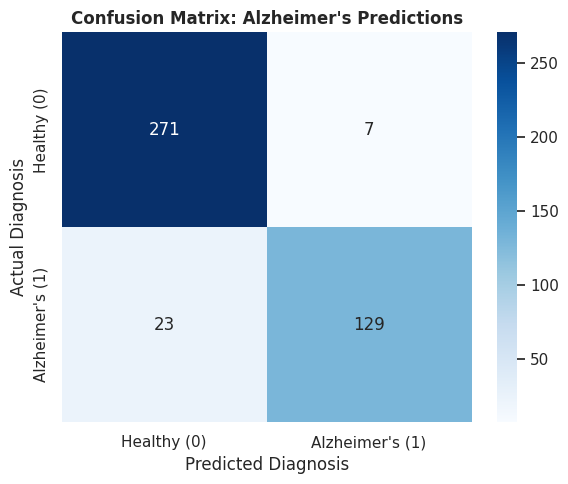

Calculating SHAP values...


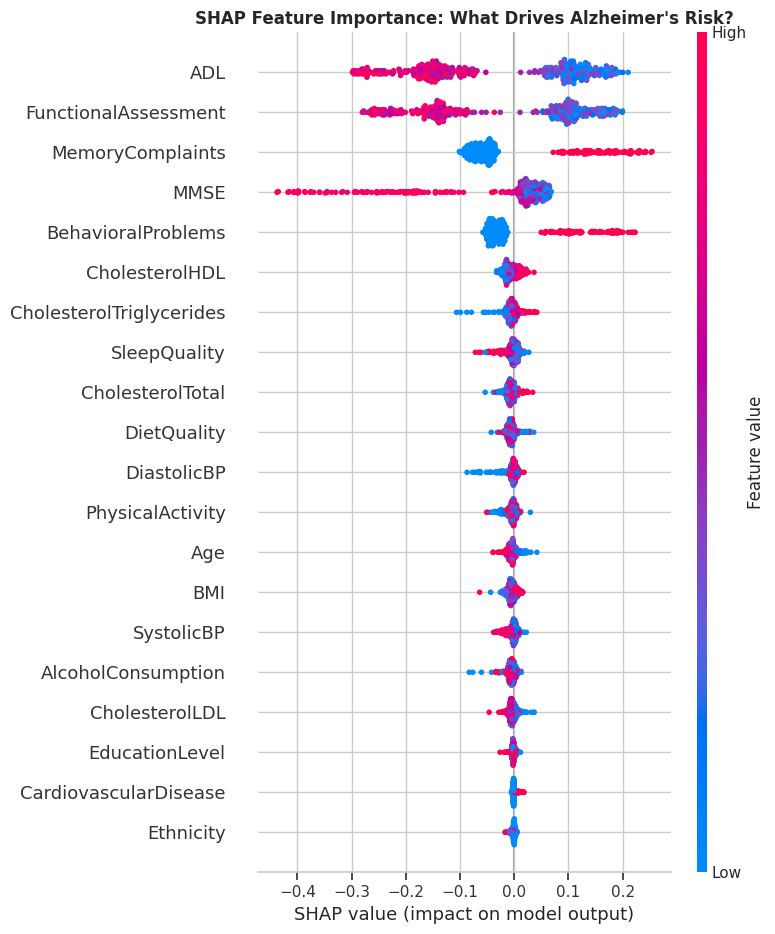

interactive(children=(IntSlider(value=0, description='Patient ID:', max=429), Output()), _dom_classes=('widget…

In [14]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option('future.no_silent_downcasting', True)

# ML Libraries
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split

# SHAP for Model Interpretability
import shap

# ---------------------------------------------------------
# 1. DATA PREPARATION
# ---------------------------------------------------------
# Drop non-predictive identifiers or duplicate target columns if present
drop_cols = ['PatientID', 'Status', 'Diagnosis', 'MMSE_Stage']
feature_cols = [c for c in df.columns if c not in drop_cols]

X = df[feature_cols].copy() # Explicitly create a copy to avoid SettingWithCopyWarning
y = df['Diagnosis']  # Assuming 1 = Alzheimer's, 0 = Healthy

# Convert all feature columns to numeric, coercing non-convertible values to NaN
for col in X.columns:
    X.loc[:, col] = pd.to_numeric(X[col], errors='coerce') # Use .loc to avoid SettingWithCopyWarning

# Impute NaN values using the mean of each column
X = X.fillna(X.mean()).infer_objects(copy=False)

# Fallback to fill any remaining NaNs (e.g., if a column was entirely NaN)
X = X.fillna(0)

# Split into 80% Training and 20% Testing (stratified to preserve class ratio)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set size: {X_train.shape[0]} patients')
print(f'Testing set size: {X_test.shape[0]} patients')

# ---------------------------------------------------------
# 2. MODEL TRAINING
# ---------------------------------------------------------
rf_model = RandomForestClassifier(
    n_estimators=100, random_state=42, class_weight='balanced'
)
rf_model.fit(X_train, y_train)

# Predictions & Probabilities
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]

# ---------------------------------------------------------
# 3. CLINICAL EVALUATION & CONFUSION MATRIX
# ---------------------------------------------------------
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
acc = accuracy_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_prob)

print('\n' + '=' * 40)
print('  CLINICAL PERFORMANCE METRICS')
print('=' * 40)
print(f'Recall (Sensitivity) : {recall:.4f}  <-- Most Critical in Medical ML')
print(f'Precision            : {precision:.4f}')
print(f'Accuracy             : {acc:.4f}')
print(f'ROC-AUC Score        : {roc_auc:.4f}')
print('=' * 40 + '\n')

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Healthy (0)', "Alzheimer's (1)"],
    yticklabels=['Healthy (0)', "Alzheimer's (1)"],
)
plt.title('Confusion Matrix: Alzheimer\'s Predictions', fontweight='bold')
plt.xlabel('Predicted Diagnosis')
plt.ylabel('Actual Diagnosis')
plt.tight_layout()
plt.show()

# ---------------------------------------------------------
# 4. EXPLAINABLE AI WITH SHAP
# ---------------------------------------------------------
print('Calculating SHAP values...')
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer(X_test)

# Plot 1: SHAP Summary Beeswarm Plot (Global Feature Importance)
# For binary classification, slice class 1 SHAP values: shap_values[:, :, 1]
plt.figure(figsize=(10, 6))
shap.summary_plot(
    shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values,
    X_test,
    show=False,
)
plt.title(
    'SHAP Feature Importance: What Drives Alzheimer\'s Risk?',
    fontsize=12,
    fontweight='bold',
)
plt.tight_layout()
plt.show()
from ipywidgets import interact
from ipywidgets.widgets import IntSlider as int_slider
import matplotlib.pyplot as plt
import shap


# Interactive Function
def explain_patient(patient_idx):
  actual_label = (
      "Alzheimer's" if y_test.iloc[patient_idx] == 1 else 'Healthy'
  )
  pred_prob = y_prob[patient_idx]

  print('=' * 60)
  print(
      f'PATIENT #{patient_idx} REPORT | Actual: {actual_label} | Predicted'
      f' Risk: {pred_prob:.1%}'
  )
  print('=' * 60)

  plt.figure(figsize=(8, 5))
  shap.plots.waterfall(
      shap_values[patient_idx, :, 1]
      if len(shap_values.shape) == 3
      else shap_values[patient_idx],
      max_display=8,
      show=False,
  )
  plt.title(
      f'SHAP Waterfall Explanation: Patient #{patient_idx}',
      fontsize=11,
      fontweight='bold',
  )
  plt.tight_layout()
  plt.show()


# Colab Slider Control
interact(
    explain_patient,
    patient_idx=int_slider(
        min=0, max=len(X_test) - 1, step=1, value=0, description='Patient ID:'
    ),
);


In [15]:
!pip install -q streamlit shap pyngrok

In [21]:
%%writefile app.py
import streamlit as st
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import recall_score, roc_auc_score, confusion_matrix
from sklearn.model_selection import train_test_split
import shap

st.set_page_config(page_title="Alzheimer's Diagnostic & MMSE App", layout="wide")

st.title("🧠 Alzheimer's Clinical Diagnostic & Explainability App")
st.markdown("An end-to-end Machine Learning pipeline featuring an interactive MMSE assessment calculator and patient-level SHAP explainability.")

# --- LOAD DATA & TRAIN MODEL ---
@st.cache_data
def load_data():
    return pd.read_csv('alzheimers_disease_data.csv')

@st.cache_resource
def train_model(df):
    # 🚨 DROP NON-NUMERIC AND METADATA COLUMNS HERE
    drop_cols = ['PatientID', 'DoctorInCharge', 'Status', 'Diagnosis', 'MMSE_Stage']

    # Filter features that exist in the dataframe and are numeric
    feature_cols = [c for c in df.columns if c not in drop_cols and pd.api.types.is_numeric_dtype(df[c])]

    X = df[feature_cols]
    y = df['Diagnosis']

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

    rf_model = RandomForestClassifier(n_estimators=100, random_state=42, class_weight='balanced')
    rf_model.fit(X_train, y_train)
    explainer = shap.TreeExplainer(rf_model)

    return rf_model, explainer, feature_cols, X_test, y_test

try:
    df = load_data()
    rf_model, explainer, feature_cols, X_test, y_test = train_model(df)
except Exception as e:
    st.error(f"Error loading dataset or training model: {e}")
    st.stop()

# Precompute predictions for test set
y_pred = rf_model.predict(X_test)
y_prob = rf_model.predict_proba(X_test)[:, 1]
shap_values = explainer(X_test)

# --- NAVIGATION ---
page = st.sidebar.radio("Navigation", ["1. Live MMSE & Risk Evaluator", "2. Model Metrics & Global SHAP", "3. Test Set Patient Inspector"])

# =========================================================
# PAGE 1: LIVE MMSE CALCULATOR & PATIENT PREDICTOR
# =========================================================
if page == "1. Live MMSE & Risk Evaluator":
    st.header("📋 Interactive MMSE Screening Questionnaire")
    st.write("Complete the standard clinical questions below to automatically calculate the MMSE score.")

    with st.expander("📝 Mini-Mental State Examination (MMSE) Form", expanded=True):
        st.subheader("1. Orientation (Max 10 points)")
        c1, c2 = st.columns(2)
        with c1:
            q_time = st.slider("Orientation to Time (Year, Season, Date, Day, Month)", 0, 5, 5)
        with c2:
            q_place = st.slider("Orientation to Place (State, County, Town, Hospital, Floor)", 0, 5, 5)

        st.subheader("2. Registration & Attention (Max 8 points)")
        c3, c4 = st.columns(2)
        with c3:
            q_reg = st.slider("Registration (Name 3 objects)", 0, 3, 3)
        with c4:
            q_att = st.slider("Attention & Calculation (Subtract 7s from 100)", 0, 5, 5)

        st.subheader("3. Recall & Language (Max 12 points)")
        c5, c6 = st.columns(2)
        with c5:
            q_recall = st.slider("Recall 3 objects named earlier", 0, 3, 3)
        with c6:
            q_lang = st.slider("Language & Praxial Tasks", 0, 9, 9)

    # Calculate Total MMSE
    calculated_mmse = q_time + q_place + q_reg + q_att + q_recall + q_lang

    st.markdown("---")
    col_s1, col_s2 = st.columns(2)
    with col_s1:
        st.metric("Total Calculated MMSE Score", f"{calculated_mmse} / 30")
    with col_s2:
        if calculated_mmse >= 25:
            st.success("MMSE Severity: **Cognitively Intact / Normal (25-30)**")
        elif calculated_mmse >= 20:
            st.warning("MMSE Severity: **Mild Cognitive Impairment (20-24)**")
        elif calculated_mmse >= 10:
            st.error("MMSE Severity: **Moderate Cognitive Impairment (10-19)**")
        else:
            st.error("MMSE Severity: **Severe Cognitive Impairment (0-9)**")

    st.markdown("---")
    st.header("🧬 Custom Patient Assessment")

    user_inputs = {}
    st.sidebar.subheader("Adjust Other Patient Biomarkers")
    for col in feature_cols:
        if col == 'MMSE':
            user_inputs['MMSE'] = calculated_mmse
        else:
            min_v = float(df[col].min())
            max_v = float(df[col].max())
            mean_v = float(df[col].mean())
            if df[col].nunique() <= 2:
                user_inputs[col] = st.sidebar.selectbox(col, options=[0, 1], index=0)
            else:
                user_inputs[col] = st.sidebar.slider(col, min_v, max_v, mean_v)

    input_df = pd.DataFrame([user_inputs])
    risk_prob = rf_model.predict_proba(input_df)[0][1]

    st.subheader("Diagnostic Risk Output")
    if risk_prob > 0.5:
        st.error(f"⚠️ **High Alzheimer's Risk: {risk_prob:.1%}**")
    else:
        st.success(f"✅ **Low Alzheimer's Risk: {risk_prob:.1%}**")

# =========================================================
# PAGE 2: MODEL METRICS & GLOBAL SHAP
# =========================================================
elif page == "2. Model Metrics & Global SHAP":
    st.header("⚡ Phase 2: Model Performance & Global SHAP")

    rec = recall_score(y_test, y_pred)
    auc = roc_auc_score(y_test, y_prob)

    m1, m2, m3 = st.columns(3)
    m1.metric("Clinical Recall (Sensitivity)", f"{rec:.1%}")
    m2.metric("ROC-AUC Score", f"{auc:.3f}")
    m3.metric("Test Set Size", f"{len(y_test)} patients")

    st.divider()

    c1, c2 = st.columns(2)
    with c1:
        st.subheader("Confusion Matrix")
        fig, ax = plt.subplots(figsize=(5, 4))
        cm = confusion_matrix(y_test, y_pred)
        sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['Healthy', "Alzheimer's"], yticklabels=['Healthy', "Alzheimer's"], ax=ax)
        plt.ylabel('Actual')
        plt.xlabel('Predicted')
        st.pyplot(fig)

    with c2:
        st.subheader("Global SHAP Feature Importance")
        fig, ax = plt.subplots(figsize=(6, 4))
        shap.summary_plot(shap_values[:, :, 1] if len(shap_values.shape) == 3 else shap_values, X_test, show=False)
        st.pyplot(fig)

# =========================================================
# PAGE 3: TEST SET PATIENT INSPECTOR
# =========================================================
elif page == "3. Test Set Patient Inspector":
    st.header("🔎 Interactive Test Set Patient Inspector")
    st.write("Inspect individual patients from the test set using a dynamic selector.")

    selected_patient_idx = st.number_input(
        f"Select Test Patient Index (0 to {len(X_test)-1}):",
        min_value=0,
        max_value=len(X_test) - 1,
        value=0,
        step=1
    )

    actual_label = "Alzheimer's" if y_test.iloc[selected_patient_idx] == 1 else "Healthy"
    patient_prob = y_prob[selected_patient_idx]

    p1, p2, p3 = st.columns(3)
    p1.metric("Patient Test ID", f"#{selected_patient_idx}")
    p2.metric("Actual Diagnosis", actual_label)
    p3.metric("Model Risk Probability", f"{patient_prob:.1%}")

    st.subheader(f"SHAP Explanation for Patient #{selected_patient_idx}")
    fig, ax = plt.subplots(figsize=(8, 4))
    shap.plots.waterfall(
        shap_values[selected_patient_idx, :, 1] if len(shap_values.shape) == 3 else shap_values[selected_patient_idx],
        max_display=8,
        show=False
    )
    st.pyplot(fig)

Overwriting app.py


In [23]:
!pip install -q pyngrok

In [25]:
from pyngrok import ngrok

# Kill any previous ngrok background sessions
ngrok.kill()

# !!! IMPORTANT: Replace 'YOUR_AUTH_TOKEN' with your actual ngrok authtoken !!!
# You can get your authtoken from https://dashboard.ngrok.com/get-started/your-authtoken
ngrok.set_auth_token('3CLOfHTBhvnNEUTCSgdrG9bKLV1_z2x2ixyoqP137uMko2zL')

# Start ngrok tunnel on port 8501
public_url = ngrok.connect(8501)
print(f'👉 CLICK THIS LINK TO OPEN YOUR APP: {public_url}')

# Run Streamlit in the background
!streamlit run app.py &>/dev/null &

👉 CLICK THIS LINK TO OPEN YOUR APP: NgrokTunnel: "https://salute-exorcist-swooned.ngrok-free.dev" -> "http://localhost:8501"


In [26]:
from google.colab import files

# Triggers a direct download prompt in your browser
files.download('app.py')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>